# Getting Started with RL

This notebook introduces the basics of reinforcement learning using our sandbox framework.

## What You'll Learn

1. How environments work (states, actions, rewards)
2. How agents interact with environments
3. Training a simple REINFORCE agent
4. Analyzing learning curves

In [3]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt

from environments.base import GymEnv
from agents.reinforce import REINFORCEAgent
from utils.logger import Logger

## 1. Understanding the Environment

Let's start with CartPole - a classic RL problem where you balance a pole on a moving cart.

In [4]:
# Create environment
env = GymEnv('CartPole-v1')

print(f"State dimension: {env.state_dim}")
print(f"Action dimension: {env.action_dim}")
print(f"Discrete actions: {env.is_discrete}")

State dimension: 4
Action dimension: 2
Discrete actions: True


CartPole has:
- **State**: 4D vector [cart_position, cart_velocity, pole_angle, pole_angular_velocity]
- **Actions**: 2 discrete actions (push left or right)
- **Reward**: +1 for each timestep the pole stays upright
- **Goal**: Keep pole balanced for 500 steps

In [5]:
# Run a random episode
state = env.reset()
episode_return = 0

print("Running random policy...")
for step in range(500):
    # Take random action
    action = np.random.randint(env.action_dim)
    
    next_state, reward, terminated, truncated, info = env.step(action)
    episode_return += reward
    
    if terminated or truncated:
        break

print(f"Episode return: {episode_return}")
print(f"Episode length: {step + 1}")

env.close()

Running random policy...
Episode return: 26.0
Episode length: 26


Random actions don't work well! The pole falls quickly. We need to learn a better policy.

## 2. Training a REINFORCE Agent

REINFORCE is the simplest policy gradient algorithm. It learns by:
1. Running episodes with current policy
2. Computing returns (cumulative rewards)
3. Increasing probability of actions that led to high returns

In [6]:
# Create fresh environment and agent
env = GymEnv('CartPole-v1')
agent = REINFORCEAgent(
    state_dim=env.state_dim,
    action_dim=env.action_dim,
    learning_rate=1e-3,
    gamma=0.99
)

logger = Logger()

# Training loop
n_episodes = 500
max_steps = 500

print(f"Training for {n_episodes} episodes...")

for episode in range(1, n_episodes + 1):
    state = env.reset()
    episode_return = 0
    
    for step in range(max_steps):
        # Agent selects action
        action = agent.act(state, training=True)
        
        # Take step
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # Learn from transition
        metrics = agent.learn(state, action, reward, next_state, done)
        
        episode_return += reward
        state = next_state
        
        if done:
            break
    
    # Log metrics
    logger.log(episode_return=episode_return)
    
    if episode % 100 == 0:
        logger.print_summary(window=100)

env.close()
print("\nTraining complete!")

Training for 500 episodes...
Episode 100 | Avg Return (last 100): 32.27 | Std: 20.63
Episode 200 | Avg Return (last 100): 153.00 | Std: 116.08
Episode 300 | Avg Return (last 100): 262.38 | Std: 119.23
Episode 400 | Avg Return (last 100): 289.87 | Std: 128.75
Episode 500 | Avg Return (last 100): 250.95 | Std: 126.72

Training complete!


## 3. Analyzing Learning

Let's visualize how the agent improved over time.

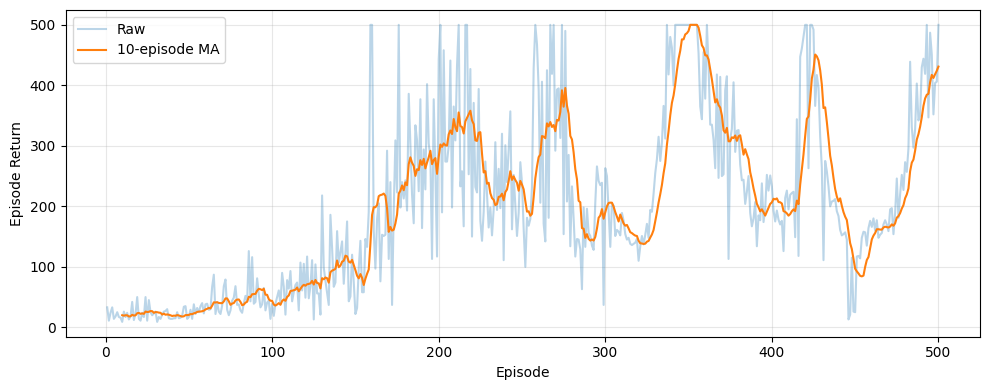

In [7]:
# Plot learning curve
logger.plot_metrics(['episode_return'], window=10)

## 4. Testing the Learned Policy

Let's see how well the trained agent performs.

In [8]:
# Test the agent
env = GymEnv('CartPole-v1')
test_returns = []

for _ in range(10):
    state = env.reset()
    episode_return = 0
    
    for _ in range(500):
        action = agent.act(state, training=False)  # Greedy action
        next_state, reward, terminated, truncated, info = env.step(action)
        episode_return += reward
        state = next_state
        
        if terminated or truncated:
            break
    
    test_returns.append(episode_return)

env.close()

print(f"Test performance over 10 episodes:")
print(f"Mean return: {np.mean(test_returns):.2f} ± {np.std(test_returns):.2f}")
print(f"Min: {np.min(test_returns):.0f}, Max: {np.max(test_returns):.0f}")

Test performance over 10 episodes:
Mean return: 469.70 ± 46.31
Min: 395, Max: 500


## Next Steps

Now that you understand the basics:

1. **Experiment with hyperparameters**: Try different learning rates, discount factors
2. **Try other environments**: MountainCar-v0, Acrobot-v1, LunarLander-v2
3. **Implement new algorithms**: DQN, A2C, PPO
4. **Add features**: Value baselines, entropy regularization, better exploration

Check out the other notebooks and `experiments/` folder for more examples!